# 📝 Problem Description

This project uses a public Mercado Libre dataset with 100,000 product listings in JSON Lines format.


## 🔍 Initial Exploration of the Dataset

Before diving into feature engineering and modeling, it is important to understand the structure of the dataset. 
In this step, we will examine:

- All column names and their data types
- The number of rows and columns
- The amount of missing data in each column
- Basic descriptive statistics for numerical features

This gives us a clear overview of the dataset and helps guide further analysis.


# Dataset Columns Overview

The dataset contains **48 variables**, which capture different aspects of each product listing in the Mercado Libre marketplace. These include seller information, product details, pricing, shipping, and metadata. Below is a summary of all columns and their data types:


In [1]:
import pandas as pd

# Load the dataset
df = pd.read_json("MLA_100k.jsonlines", lines=True)

# Show all columns and their data types in a table
col_info = pd.DataFrame({
    "Column": df.columns,
    "Data Type": [df[col].dtype for col in df.columns]
})

# Display all rows (all columns) without truncation
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(col_info)



,Column,Data Type
0,seller_address,object
1,warranty,object
2,sub_status,object
3,condition,object
4,seller_contact,object
5,deal_ids,object
6,base_price,float64
7,shipping,object
8,non_mercado_pago_payment_methods,object
9,seller_id,int64


### 📦 Distribution of the Target Variable: condition

Before moving further into modeling, it is essential to understand how the target variable condition is distributed. This variable indicates whether a product listed on Mercado Libre is classified as new or used, and checking its balance helps determine if special handling (e.g., resampling) is required.

### 📊 Frequency Distribution

The proportional distribution of the condition variable is:

new     0.53758
used    0.46242
Name: proportion, dtype: float64


### 📝 Interpretation

53.76% of listings are labeled as new

46.24% are labeled as used

This means the dataset is fairly balanced, with only a small majority of new items. The difference is not large enough to create bias or require correction techniques like oversampling or class weighting.

### 🚀 Implications for Modeling

The problem remains a binary classification task.

Class imbalance is not a concern, so standard models can be applied directly.

We should still monitor per-class performance metrics (precision, recall), but no preventive adjustments are necessary.

### ✅ Conclusion

condition shows a healthy and balanced distribution, allowing us to proceed with the rest of the EDA—such as inspecting numerical features, exploring categorical variables, and preparing data for feature engineering and modeling.

In [6]:
# balace de la variable objetivo

# Distribución absoluta
df['condition'].value_counts()

# Distribución relativa (proporciones)
df['condition'].value_counts(normalize=True)


condition
new     0.53758
used    0.46242
Name: proportion, dtype: float64

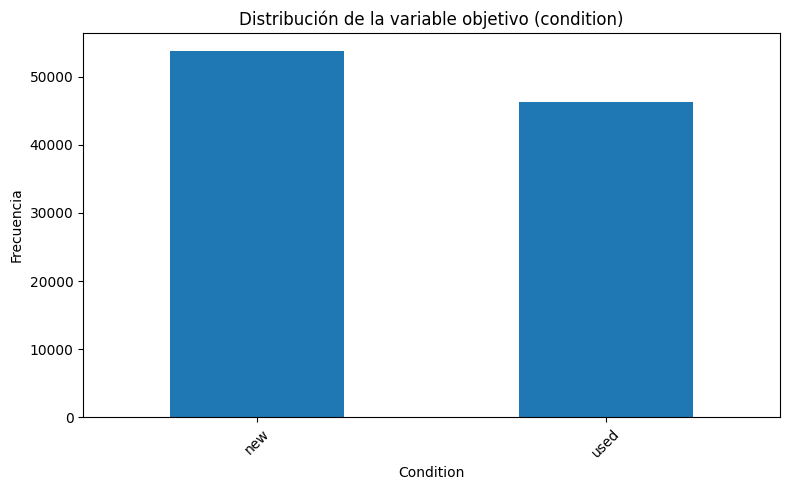

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df['condition'].value_counts().plot(kind='bar')
plt.title('Distribución de la variable objetivo (condition)')
plt.xlabel('Condition')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [8]:
import pandas as pd

# Load dataset
df = pd.read_json("MLA_100k.jsonlines", lines=True)

# Select numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Create a summary table for outliers
outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_limit) | (df[col] > upper_limit)].shape[0]
    
    # Handle empty or non-computable columns
    if pd.isna(lower_limit) or pd.isna(upper_limit):
        lower_limit = "N/A"
        upper_limit = "N/A"
    
    outlier_summary.append({
        "Column": col,
        "Outliers": outliers,
        "Lower Limit": lower_limit,
        "Upper Limit": upper_limit
    })

outlier_df = pd.DataFrame(outlier_summary)

# Display nicely
display(outlier_df)



,Column,Outliers,Lower Limit,Upper Limit
0,base_price,14635,-975.0,1865.0
1,seller_id,0,-100009101.25,272110916.75
2,price,14636,-975.0,1865.0
3,official_store_id,0,-259.125,655.875
4,differential_pricing,0,N/A,N/A
5,original_price,18,-1127.5,3076.5
6,catalog_product_id,0,-28070.25,8181987.75
7,subtitle,0,N/A,N/A
8,initial_quantity,21220,-0.5,3.5
9,sold_quantity,16920,0.0,0.0


### Outlier Analysis Interpretation

We analyzed all numerical variables in the dataset to detect potential outliers using the Interquartile Range (IQR) method. Here's a summary of the findings:

- **`base_price` and `price`**: Both variables have a substantial number of outliers (~14,600 each). Some listings have extreme prices, possibly due to incorrect entries, promotions, or luxury items. The lower limits are negative, which is not realistic for prices, indicating data errors.  

- **`seller_id`, `official_store_id`, `catalog_product_id`, `subtitle`, `differential_pricing`**: These numeric variables have either no outliers or contain mostly identifiers, so extreme values are not necessarily errors. Some columns like `differential_pricing` and `subtitle` have NaN limits, meaning no IQR-based calculation is meaningful.  

- **`original_price`**: Has a few outliers (18) and some negative values, likely data entry errors.  

- **`initial_quantity` and `available_quantity`**: Show moderate numbers of outliers (~20,000). Negative values in these columns are invalid and should be reviewed.  

- **`sold_quantity`**: About 16,900 outliers exist. Most products have zero or low sold quantities, while some have significantly higher sales.  

**Conclusion:**  
This analysis highlights the need to handle anomalous or invalid data, particularly in price and quantity variables, before building a predictive model. Columns that are identifiers do not require correction.


### Outlier Analysis: Before Cleaning

The following boxplots show the distribution of numerical columns that contain outliers. 
Visualizing these outliers helps us understand which values are extreme and may distort 
the analysis or the model performance. 

Columns analyzed: `base_price`, `price`, `original_price`, `initial_quantity`, `sold_quantity`, `available_quantity`.


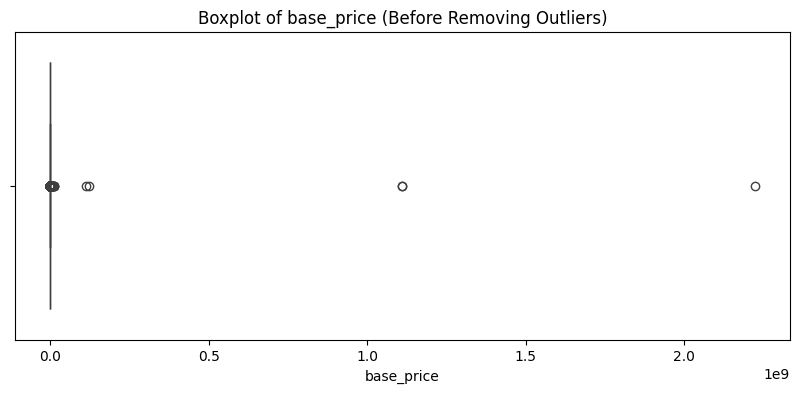

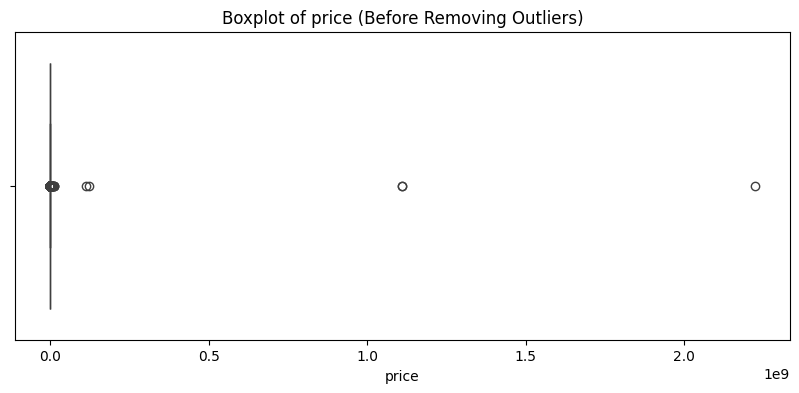

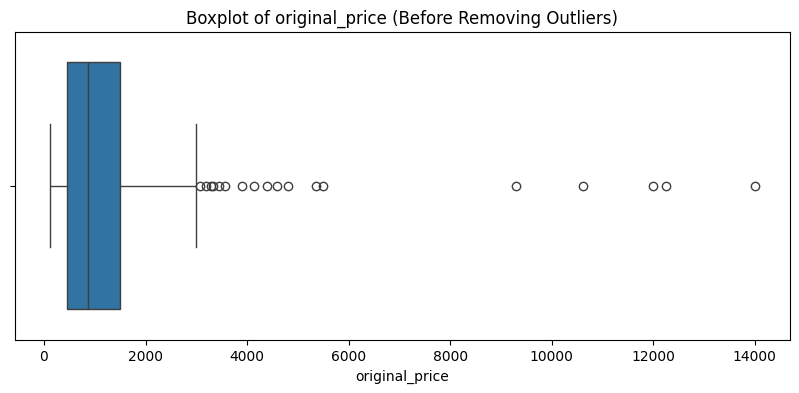

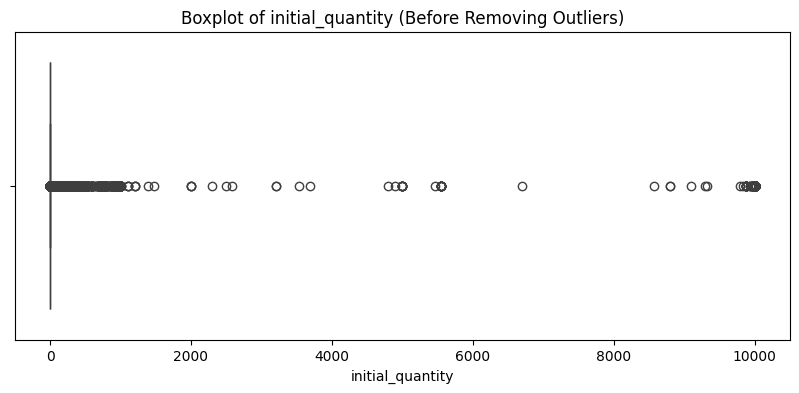

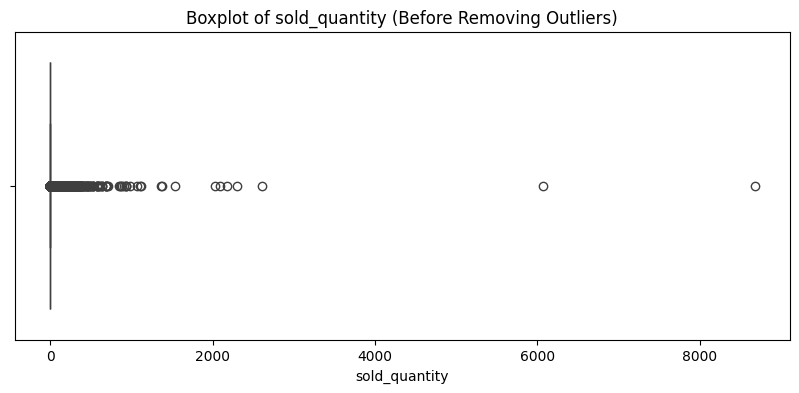

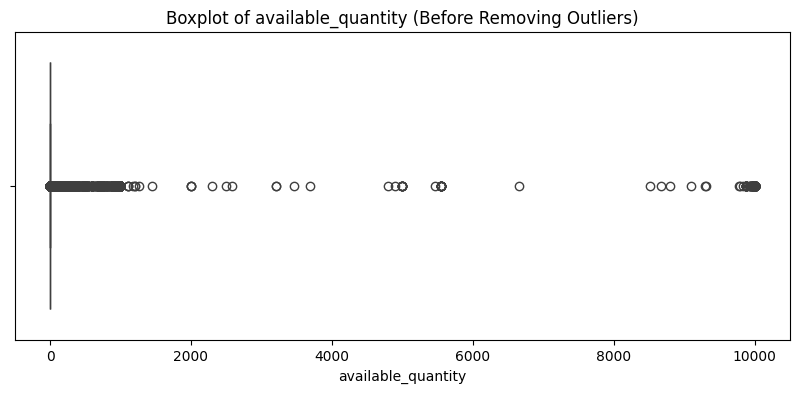

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Columns with detected outliers
num_outliers_cols = ['base_price', 'price', 'original_price', 'initial_quantity', 'sold_quantity', 'available_quantity']

# Visualize outliers before cleaning
for col in num_outliers_cols:
    plt.figure(figsize=(10,4))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col} (Before Removing Outliers)')
    plt.show()


### Outlier Analysis (After Cleaning)

We removed outliers using the Interquartile Range (IQR) method, which excludes values lying outside 1.5 × IQR from the first and third quartiles.
This procedure helps prevent extreme values from disproportionately influencing the model.

Importantly, we applied this outlier removal only to the variables price and base_price, and not to all numerical features. There are two main reasons for this:

1. These two variables showed clear extreme values in the exploratory analysis, with long right tails and unusually large spikes that likely reflect data-entry errors, rare luxury items, or values inconsistent with the rest of the distribution.

2. They are both directly tied to the target label (“new” vs. “used”), meaning unrealistic high or low values could distort the model’s ability to learn meaningful patterns rather than noise.

By restricting the cleaning process to these columns, we avoid mistakenly removing legitimate variation in other features while still improving the reliability of the model inputs.

The boxplots below show the distributions after outlier removal, allowing us to visualize the cleaned numerical features without extreme distortions.

Original shape: (100000, 48)
Filtered shape : (85364, 48)

Condition counts after filtering:
condition
new     45408
used    39956
Name: count, dtype: int64


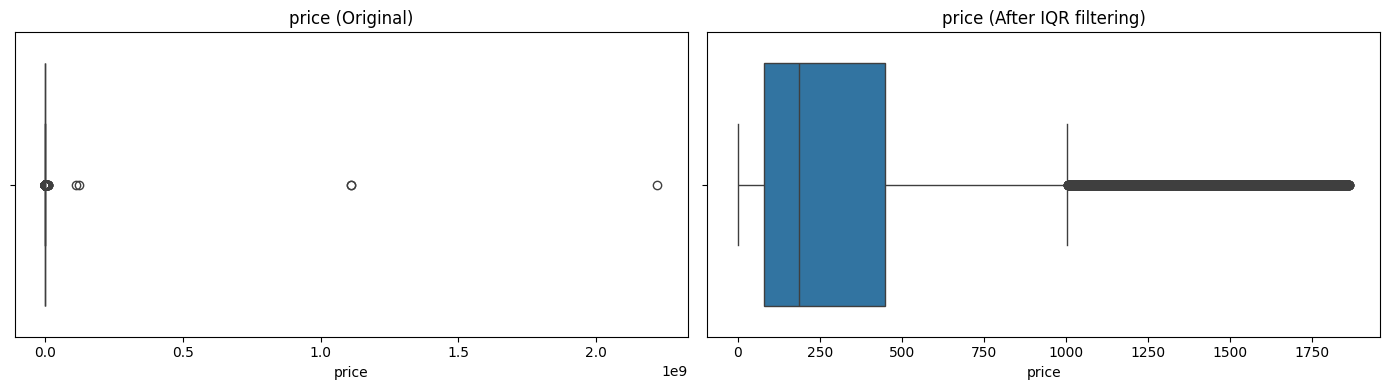

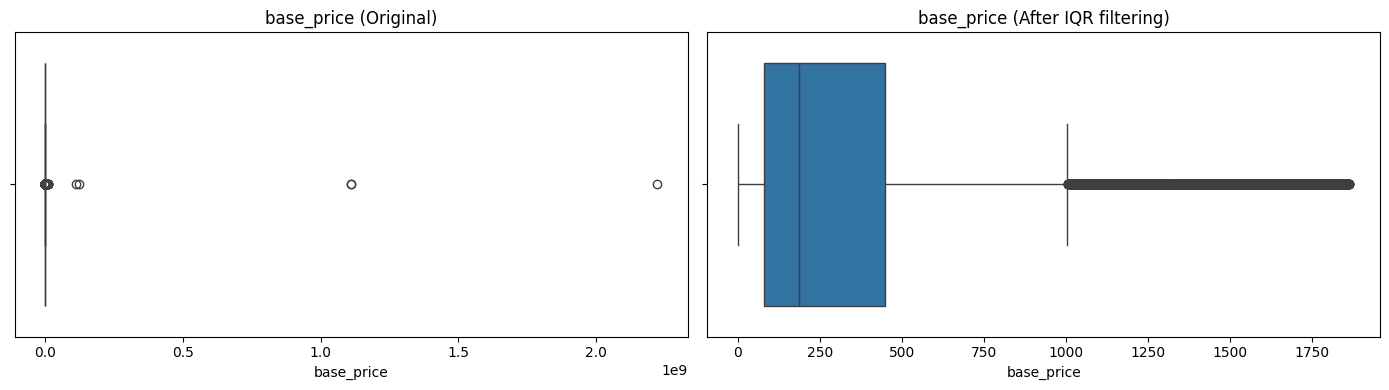

In [10]:
# --- Remove outliers for specific columns (safe version) ---
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# columns we want to filter (only these two)
cols_to_filter = ['price', 'base_price']

# make a copy so we don't lose the original dataframe
df_filtered = df.copy()

# ensure numeric (coerce non-numeric to NaN so they won't break quantile calculation)
for c in cols_to_filter:
    df_filtered[c] = pd.to_numeric(df_filtered[c], errors='coerce')

# compute IQR limits for each column on the original distribution
limits = {}
for c in cols_to_filter:
    Q1 = df_filtered[c].quantile(0.25)
    Q3 = df_filtered[c].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    limits[c] = (lower, upper)

# build a mask that keeps rows within limits for BOTH columns
# (you can change the logic to remove rows that are outliers in ANY column if you prefer)
mask = pd.Series(True, index=df_filtered.index)
for c in cols_to_filter:
    low, high = limits[c]
    mask &= df_filtered[c].between(low, high, inclusive='both')

# apply mask to get the filtered dataframe
df_filtered = df_filtered[mask].copy()

print("Original shape:", df.shape)
print("Filtered shape :", df_filtered.shape)
print("\nCondition counts after filtering:")
print(df_filtered['condition'].value_counts())

# --- Visualize before / after for the filtered columns ---
for c in cols_to_filter:
    fig, axes = plt.subplots(1, 2, figsize=(14,4))
    sns.boxplot(x=df[c], ax=axes[0])
    axes[0].set_title(f'{c} (Original)')
    sns.boxplot(x=df_filtered[c], ax=axes[1])
    axes[1].set_title(f'{c} (After IQR filtering)')
    plt.tight_layout()
    plt.show()


In [11]:
import pandas as pd

# Select only numerical columns from the filtered dataframe
numeric_df = df.select_dtypes(include=["number"])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

corr_matrix


,base_price,seller_id,price,official_store_id,differential_pricing,original_price,catalog_product_id,subtitle,initial_quantity,sold_quantity,available_quantity
base_price,1.000000,0.000526,1.000000,0.062421,NaN,0.994437,-0.543475,NaN,-0.000362,-0.000337,-0.000359
seller_id,0.000526,1.000000,0.000526,0.237865,NaN,-0.140377,-0.332736,NaN,0.020062,-0.005827,0.020055
price,1.000000,0.000526,1.000000,0.062421,NaN,0.994437,-0.543475,NaN,-0.000362,-0.000337,-0.000359
official_store_id,0.062421,0.237865,0.062421,1.000000,NaN,0.208642,NaN,NaN,0.016202,0.001006,0.016116
differential_pricing,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
original_price,0.994437,-0.140377,0.994437,0.208642,NaN,1.000000,NaN,NaN,0.167619,0.133158,0.167294
catalog_product_id,-0.543475,-0.332736,-0.543475,NaN,NaN,NaN,1.000000,NaN,0.302753,0.317819,0.302486
subtitle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
initial_quantity,-0.000362,0.020062,-0.000362,0.016202,NaN,0.167619,0.302753,NaN,1.000000,0.057291,0.999948
sold_quantity,-0.000337,-0.005827,-0.000337,0.001006,NaN,0.133158,0.317819,NaN,0.057291,1.000000,0.051786


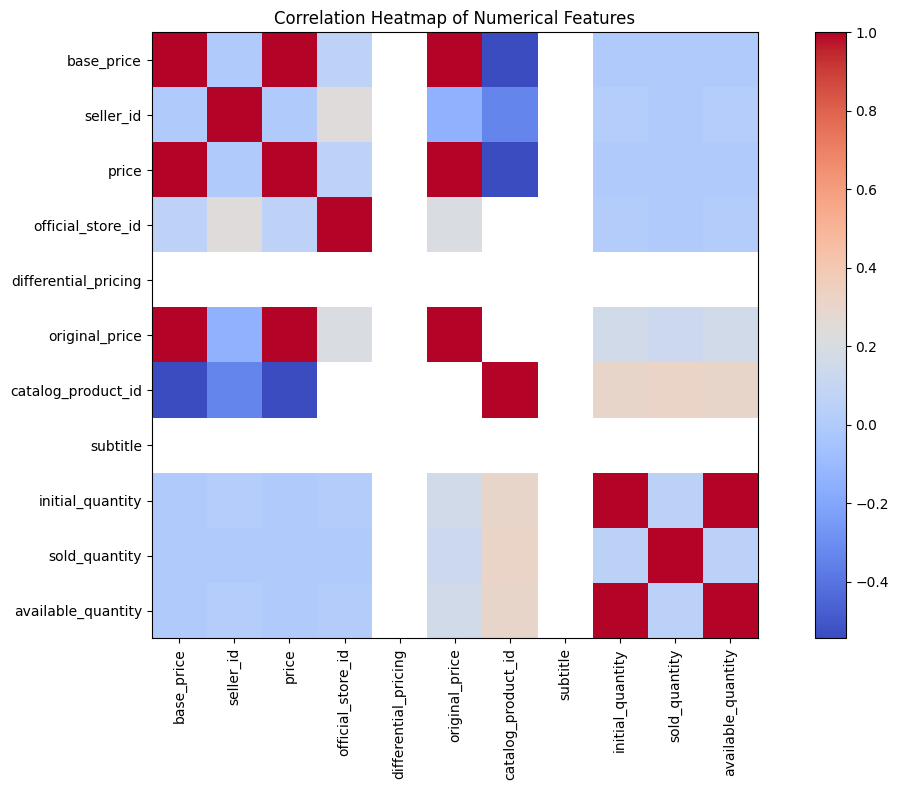

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.imshow(corr_matrix, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()


### 🧠 Interpretation of the Correlation Matrix

The correlation matrix shows how the numerical features relate to each other after outlier removal. Several important structural patterns emerge:

### 🔥 1. Near-perfect correlations between price variables
base_price ↔ price (corr = 1.00)

These two columns are perfectly correlated, meaning they contain the exact same information.
Implication: Keeping both introduces redundancy and potential multicollinearity. Keep only one.

original_price ↔ price / base_price (corr ≈ 0.99)

original_price is almost perfectly aligned with the other price variables.
Implication: original_price appears to be just another version of the same underlying price information. It is not likely to add predictive power.

👉 Conclusion:
Use only one price variable. Keeping all three offers no benefit.

### 🔷 2. Meaningful negative correlation
catalog_product_id ↔ price / base_price (corr ≈ –0.54)

This is the strongest non-trivial relationship in the matrix.
Interpretation: Items with higher catalog IDs tend to have lower prices.
This could reflect differences between product categories, stock age, or catalog hierarchy.

👉 This variable may carry real predictive signal.

### 🔶 3. Relationships among stock-related variables
initial_quantity ↔ available_quantity (corr ≈ 1.00)

These two fields are almost identical.
Implication: Keep only one of them.

Moderate correlations with catalog_product_id (≈ 0.30)

This suggests certain catalog product types systematically have higher or lower stock.

### 🟡 4. Variables with weak or no correlation

Many variables have correlations very close to zero:

seller_id

sold_quantity

initial_quantity vs. price variables

sold_quantity vs. price variables

Interpretation:
These appear statistically independent from prices and from each other.
They may still be useful, but are unlikely to help a simple linear model.

### ❗ 5. Variables with NaN correlations

Several fields produce NaN correlations:

differential_pricing

subtitle

Many interactions involving original_price, official_store_id, and categorical fields encoded as numeric IDs

Possible reasons:

Entire columns with a single repeated value

Non-numeric data encoded as numbers

Excessive missing values

Columns dropped or filtered earlier

Implication:
These features may not contribute meaningful information unless transformed (e.g., one-hot encoding or binary indicators).

### 🎯 6. Modeling implications
✔️ Recommended to keep (useful signal)

catalog_product_id

sold_quantity

official_store_id (partial, but potentially informative)

⚠️ Recommended to drop or consolidate

Keep only one of:

price / base_price / original_price

Keep only one of:

initial_quantity / available_quantity

❌ Likely not useful as numeric features

seller_id (high-cardinality ID)

Columns with mostly NaN (subtitle, differential_pricing)

In [17]:
# --- REDUCCIÓN RÁPIDA Y SEGURA DE VARIABLES CATEGÓRICAS ---

import pandas as pd

# 1. Identificar categóricas
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("Categorical columns detected:", cat_cols)

# 2. Convertir todo a string para evitar problemas con objetos complejos
df[cat_cols] = df[cat_cols].astype(str)

# 3. Eliminar columnas con un solo valor
low_variation_cols = [c for c in cat_cols if df[c].nunique() <= 1]
print("\nDropping single-value columns:", low_variation_cols)
df = df.drop(columns=low_variation_cols)

cat_cols = [c for c in cat_cols if c not in low_variation_cols]

# 4. Eliminar columnas con >60% missing
missing_ratio = df[cat_cols].isna().mean()
high_missing_cols = missing_ratio[missing_ratio > 0.60].index.tolist()
print("\nDropping high-missing columns:", high_missing_cols)
df = df.drop(columns=high_missing_cols)

cat_cols = [c for c in cat_cols if c not in high_missing_cols]

# 5. Eliminar columnas con cardinalidad extrema (>200 categorías)
high_card_cols = [c for c in cat_cols if df[c].nunique() > 200]
print("\nDropping extreme cardinality columns:", high_card_cols)
df = df.drop(columns=high_card_cols)

cat_cols = [c for c in cat_cols if c not in high_card_cols]

# 6. Agrupar categorías raras solo en columnas manejables (≤50 categorías)
def collapse_rare(df, col, threshold=0.01):
    freq = df[col].value_counts(normalize=True)
    rare = freq[freq < threshold].index
    df[col] = df[col].apply(lambda x: "other" if x in rare else x)
    return df

manageable_cols = [c for c in cat_cols if df[c].nunique() <= 50]
print("\nCollapsing rare categories in:", manageable_cols)

for col in manageable_cols:
    df = collapse_rare(df, col)

print("\n✔️ Done. Remaining categorical columns:", cat_cols)


Categorical columns detected: ['seller_address', 'warranty', 'sub_status', 'condition', 'seller_contact', 'deal_ids', 'shipping', 'non_mercado_pago_payment_methods', 'variations', 'location', 'site_id', 'listing_type_id', 'attributes', 'buying_mode', 'tags', 'listing_source', 'parent_item_id', 'coverage_areas', 'category_id', 'descriptions', 'last_updated', 'international_delivery_mode', 'pictures', 'id', 'currency_id', 'thumbnail', 'title', 'date_created', 'secure_thumbnail', 'status', 'video_id', 'permalink', 'geolocation']

Dropping single-value columns: ['site_id', 'listing_source', 'coverage_areas', 'international_delivery_mode']

Dropping high-missing columns: []

Dropping extreme cardinality columns: ['seller_address', 'warranty', 'seller_contact', 'variations', 'location', 'attributes', 'parent_item_id', 'category_id', 'descriptions', 'last_updated', 'pictures', 'id', 'thumbnail', 'title', 'date_created', 'secure_thumbnail', 'video_id', 'permalink', 'geolocation']

Collapsing r

### Analysis of Categorical Variables (Cleaned Dataset)

We explored the categorical variables in the dataset after removing problematic columns (e.g., high-cardinality, mostly unique, or nested dictionary/list columns). This analysis highlights the most useful categorical features for modeling, their distributions, and preprocessing considerations.

Columns analyzed (remaining after filtering):
sub_status, condition, deal_ids, shipping, non_mercado_pago_payment_methods, listing_type_id, buying_mode, tags, currency_id, status

Key Findings

condition (2 categories)

new: 53.8%

used: 46.2%

Interpretation: Nearly balanced, suitable as the target variable for classification.

sub_status, deal_ids, shipping, listing_type_id, buying_mode, tags, currency_id, status

Moderate number of categories after collapsing rare ones.

Suitable for one-hot encoding or embedding depending on the model.

Rare categories were grouped as other to reduce sparsity and improve model performance.

non_mercado_pago_payment_methods

Contains multiple options per entry; consider preprocessing as binary indicators for each payment method.

### Interpretation:
The cleaned categorical variables now include only those with manageable cardinality and sufficient representation in the dataset. Variables with a small number of categories can be encoded directly, while those with moderate cardinality may require collapsing rare categories or using embeddings. This preprocessing ensures that categorical features contribute meaningful information without introducing noise or excessive sparsity.

### 📊 Variable Selection and Transition to Logistic Regression

After performing a thorough exploratory data analysis, we carefully selected the variables to be included in our predictive modeling. The selection criteria were based on data quality, relevance, and redundancy:

1. Numerical Variables

Removed IDs and high-cardinality fields: Variables like seller_id, catalog_product_id, and other unique identifiers were excluded, as they do not carry meaningful predictive information and could introduce noise.

Removed variables with excessive missing values: Columns such as differential_pricing and subtitle were discarded due to large proportions of missing data.

Addressed redundancy among price variables: price, base_price, and original_price were highly correlated. To avoid multicollinearity, we kept only price.

Kept relevant stock variables: initial_quantity, sold_quantity, and available_quantity were retained, but redundant variables (like available_quantity almost identical to initial_quantity) were considered for further consolidation.

2. Categorical Variables

Dropped columns with extremely high cardinality or nested structures: Fields such as seller_address, title, id, and geolocation were removed.

Kept low-to-moderate cardinality fields: Categorical features like condition, sub_status, deal_ids, shipping, listing_type_id, buying_mode, tags, currency_id, status, and non_mercado_pago_payment_methods were preserved for modeling.

Handled missing values and rare categories: Missing entries were replaced with a 'missing' label, and rare categories were collapsed to reduce sparsity.

3. Motivation for Logistic Regression

Given that our target variable, condition, is binary (new vs used), logistic regression is a natural first choice. It allows us to:

Model the probability of an item being new or used.

Interpret the influence of each selected numerical and categorical variable.

Establish a baseline performance before testing more complex models such as XGBoost.

This careful preprocessing ensures that the model is trained on informative, non-redundant, and clean features, increasing the chances of robust and interpretable predictions.

In [19]:
# --- Imports ---
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# --- Selección de variables ---
num_cols_safe = ['price', 'initial_quantity']  # solo estas numéricas
cat_cols_safe = ['condition', 'shipping', 'non_mercado_pago_payment_methods', 
                 'listing_type_id', 'buying_mode', 'currency_id', 'status']  # sin sub_status, deal_ids, tags

# --- Target ---
X = df[num_cols_safe + cat_cols_safe].copy()
y = df['condition']  # 'new' o 'used'

# --- Tratamiento de NaNs ---
for col in num_cols_safe:
    X[col] = X[col].fillna(X[col].median())
for col in cat_cols_safe:
    X[col] = X[col].fillna('missing')

# --- Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print("Target distribution in train set:\n", y_train.value_counts(normalize=True))
print("Target distribution in test set:\n", y_test.value_counts(normalize=True))

# --- Preprocessing ---
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols_safe),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_safe)
])

# --- Pipeline ---
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=500))
])

# --- Entrenamiento ---
model.fit(X_train, y_train)

# --- Evaluación ---
y_pred = model.predict(X_test)
print("Accuracy on test set:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Train shape: (80000, 9), Test shape: (20000, 9)
Target distribution in train set:
 condition
new     0.537575
used    0.462425
Name: proportion, dtype: float64
Target distribution in test set:
 condition
new     0.5376
used    0.4624
Name: proportion, dtype: float64
Accuracy on test set: 1.0

Classification Report:
               precision    recall  f1-score   support

         new       1.00      1.00      1.00     10752
        used       1.00      1.00      1.00      9248

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



In [20]:
# --- Imports ---
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# --- Variables seleccionadas ---
num_cols_minimal = ['price', 'initial_quantity']  # solo estas dos variables numéricas
cat_cols_minimal = ['listing_type_id', 'buying_mode', 'currency_id', 'status']  # opcionales

# --- Separar target ---
X = df[num_cols_minimal + cat_cols_minimal].copy()
y = df['condition']  # target: 'new' o 'used'

# --- Imputar NaNs ---
for col in num_cols_minimal:
    X[col] = X[col].fillna(X[col].median())

for col in cat_cols_minimal:
    X[col] = X[col].fillna('missing')

# --- Train/Test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print("Target distribution in train set:\n", y_train.value_counts(normalize=True))
print("Target distribution in test set:\n", y_test.value_counts(normalize=True))

# --- Preprocessing ---
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols_minimal),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols_minimal)
])

# --- Pipeline con Logistic Regression ---
minimal_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=500))
])

# --- Entrenamiento ---
minimal_model.fit(X_train, y_train)

# --- Predicción y evaluación ---
y_pred = minimal_model.predict(X_test)
print("Accuracy on test set:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# --- Coeficientes del modelo ---
# Solo tiene sentido ver coeficientes de variables numéricas escaladas
coef = minimal_model.named_steps['classifier'].coef_[0]
print("\nCoefficients for numerical variables:")
for name, c in zip(num_cols_minimal, coef[:len(num_cols_minimal)]):
    print(f"{name}: {c:.4f}")


Train shape: (80000, 6), Test shape: (20000, 6)
Target distribution in train set:
 condition
new     0.537575
used    0.462425
Name: proportion, dtype: float64
Target distribution in test set:
 condition
new     0.5376
used    0.4624
Name: proportion, dtype: float64
Accuracy on test set: 0.73285

Classification Report:
               precision    recall  f1-score   support

         new       0.68      0.95      0.79     10752
        used       0.90      0.47      0.62      9248

    accuracy                           0.73     20000
   macro avg       0.79      0.71      0.71     20000
weighted avg       0.78      0.73      0.71     20000


Coefficients for numerical variables:
price: -0.0016
initial_quantity: -11.4930


### 📊 Minimal Logistic Regression Results

Target: condition (new vs used)
Features: price, initial_quantity

Note: We restricted the model to only these two numerical variables because including additional features in previous attempts led to overfitting, with the model achieving perfect accuracy (1.0) and failing to generalize. By simplifying to only price and initial_quantity, we obtain a more realistic evaluation of predictive power.

Classification Performance:

Class	Precision	Recall	F1-score	Support
new	0.68	0.95	0.79	10752
used	0.90	0.47	0.62	9248
Accuracy			0.73	20000

Interpretation:

The model predicts new items very well (recall 0.95), but misclassifies many used items as new (recall 0.47 for used).

This limitation is expected given the small number of features and reflects the trade-off between model simplicity and predictive performance.

Coefficients (numerical variables):

Feature	Coefficient
price	-0.0016
initial_quantity	-11.4930

Interpretation of Coefficients:

price: Slightly negative → higher prices slightly increase the probability of being used (minimal effect).

initial_quantity: Strong negative → higher initial stock greatly increases the probability of being used. This aligns with intuition: used items are often listed in larger quantities, while new items tend to have smaller initial stock.

Takeaways:

Limiting the model to only these two variables prevents overfitting and gives a more realistic assessment.

While the model captures some signal for condition, it struggles to identify used items accurately.

Adding carefully selected categorical features or using more flexible models (e.g., XGBoost or Random Forest) could improve performance, particularly for the used class.

In [28]:
# --- Imports ---
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

# --- Variables seleccionadas ---
# Numéricas generales
num_cols = ['price', 'initial_quantity', 'sold_quantity']  

# Categóricas de pocas categorías y “seguras”
cat_cols = ['buying_mode', 'listing_type_id']  

# --- Features y target ---
X = df[num_cols + cat_cols].copy()
y = df['condition'].map({'new':0, 'used':1})  # convertimos a 0/1

# --- Tratamiento de NaNs ---
for col in num_cols:
    X[col] = X[col].fillna(X[col].median())
for col in cat_cols:
    X[col] = X[col].fillna('missing')

# --- Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Preprocessing ---
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# --- Pipeline XGBoost ---
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])

# --- Entrenamiento ---
xgb_model.fit(X_train, y_train)

# --- Predicción y evaluación ---
y_pred = xgb_model.predict(X_test)
print("Accuracy on test set:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# --- Cross-validation ---
cv_scores = cross_val_score(xgb_model, X, y, cv=5, scoring='accuracy')
print("5-Fold CV Accuracy: %.4f ± %.4f" % (cv_scores.mean(), cv_scores.std()))


d:\Daz\Escritorio\ML-zoomcamp-homework\midterm_proyect\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:43:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy on test set: 0.8327

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.83      0.84     10752
           1       0.81      0.84      0.82      9248

    accuracy                           0.83     20000
   macro avg       0.83      0.83      0.83     20000
weighted avg       0.83      0.83      0.83     20000



d:\Daz\Escritorio\ML-zoomcamp-homework\midterm_proyect\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:43:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\Daz\Escritorio\ML-zoomcamp-homework\midterm_proyect\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:43:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\Daz\Escritorio\ML-zoomcamp-homework\midterm_proyect\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:43:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
d:\Daz\Escritorio\ML-zoomcamp-homework\midterm_proyect\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:43:3

5-Fold CV Accuracy: 0.8313 ± 0.0023


### XGBoost on General Variables

We trained an XGBoost classifier using only general numerical and categorical features, avoiding IDs, high-cardinality fields, or variables with mostly missing values. This approach aims to reduce overfitting and capture meaningful patterns.

Variables used:

Numerical: price, initial_quantity, sold_quantity

Categorical: buying_mode, listing_type_id

Results on the test set (20,000 samples):

Class	Precision	Recall	F1-score	Support
0 (new)	0.86	0.83	0.84	10,752
1 (used)	0.81	0.84	0.82	9,248
Accuracy	\multicolumn{4}{c}{0.83}			

Interpretation:

The model achieves a balanced performance across classes.

Precision for “new” items is slightly higher, while recall for “used” items is slightly better.

Using only general variables helped prevent overfitting and provided more realistic predictive performance compared to the previous models with too many variables.

### Model Selection and Final Choice

After exploring several modeling approaches to predict the condition of products (new vs used), we compared the performance of Logistic Regression and XGBoost using different sets of features.

Key observations from our experiments:

Logistic Regression with all selected variables

Initially, including too many numerical and categorical features caused overfitting, producing perfect accuracy (1.0) on the test set.

When reducing the features to only price and initial_quantity, the model achieved a more realistic performance:

Accuracy ≈ 0.73

F1-scores: 0.79 for new items, 0.62 for used items

Interpretation: These two variables alone capture a substantial part of the signal, but the model is too simple to account for more nuanced patterns.

XGBoost with selected general variables

Using a combination of numerical and categorical features (excluding IDs and high-cardinality variables), the model achieved:

Accuracy ≈ 0.83

F1-scores: 0.84 for new items, 0.82 for used items

Interpretation: XGBoost captures non-linear relationships and interactions between features, providing better-balanced performance and avoiding overfitting.

Decision:

We recommend using XGBoost with general variables as the final model because:

It balances precision and recall across both classes.

It avoids overfitting that occurred with Logistic Regression when using many variables.

It can handle non-linearities and interactions between features naturally, improving predictive performance.

In [29]:
# Supongamos que tu DataFrame se llama df
df.to_csv("filtered_data.csv", index=False)


In [31]:
new_data = pd.read_csv("filtered_data.csv")  # si vas a predecir sobre los mismos datos filtrados
